In [1]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
import math
import scipy
from pathlib import Path
import sys
import os
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
sys.path.append("../src")
from custom_distance import KL, conditionKL



import plotly.express as px

import plotly.io as pio
pio.renderers.default = 'iframe' # or 'notebook' or 'colab' or 'jupyterlab' iframe

from plotly.express.colors import sample_colorscale

import plotly.graph_objects as go


warnings.filterwarnings("ignore")


def get_regression(x, y):
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


def get_coefLog10(x, y):
    x = np.log10(x)
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


In [2]:
!ls -lrt ../output/regression_onlyAlpha_Train_1_SHACBalanceAlpha

total 640
-rw-r--r-- 1 xiruod domain users 655253 Apr  4 16:55 binaryUnigram_ntest_200_l2_C1_V10.pkl


In [3]:
!ls -lrt ../output/regression_ReSampling_HateSpeechBalanceAlpha

total 9496
-rw-r--r-- 1 xiruod domain users 3811944 Apr  4 05:03 Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-Sentence-BERT-ntest_1000-l2-C1-V10.pkl
-rw-r--r-- 1 xiruod domain users 2095396 Apr  5 17:24 Multiplier_1-p_pos_train_z0_target_0.6-p_pos_train_z1_target_0.6-binaryUnigram-ntest_200-l2-C1-V10.pkl
-rw-r--r-- 1 xiruod domain users 3811944 Apr  6 14:35 Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-binaryUnigram-ntest_1000-l2-C1-V10.pkl


In [4]:
!ls -lrt ../output/regression_ReSampling_SHACBalanceAlpha

total 68576
-rw-r--r-- 1 xiruod domain users 18923384 Apr  4 14:45 Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-binaryUnigram-ntest_200-l2-C1-V10.pkl
-rw-r--r-- 1 xiruod domain users 18729744 Apr  4 23:07 Multiplier_1-p_pos_train_z0_target_0.4-p_pos_train_z1_target_0.4-binaryUnigram-ntest_200-l2-C1-V10.pkl
-rw-r--r-- 1 xiruod domain users 18729744 Apr  5 10:56 Multiplier_1-p_pos_train_z0_target_0.4-p_pos_train_z1_target_0.4-Sentence-BERT-ntest_200-l2-C1-V10.pkl
-rw-r--r-- 1 xiruod domain users 13834224 Apr  5 16:36 Multiplier_1-p_pos_train_z0_target_0.6-p_pos_train_z1_target_0.6-binaryUnigram-ntest_200-l2-C1-V10.pkl


In [5]:
!ls -lrt ../output/tmpData/SHAC

total 473084
-rw-r--r-- 1 xiruod domain users 1209505 Apr  4 16:15 OriginalWeightsEdited-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_5.pkl
-rw-r--r-- 1 xiruod domain users 1209505 Apr  4 23:54 OriginalWeightsEdited-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_5.pkl
-rw-r--r-- 1 xiruod domain users  760060 Apr  5 19:38 OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_5.pkl
drwxr-xr-x 2 xiruod domain users   12288 Apr 22 23:34 archive
-rw-r--r-- 1 xiruod domain users 9451886 Apr 24 20:45 Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl
-rw-r--r-- 1 xiruod domain users 9451886 Apr 24 20:47 Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5.pkl
-rw-r--r-- 1 xiruod domain users 9451886 Apr 24 21:06 Eval-set-11063-

In [6]:
!ls -lrt ../output/tmpData/HateSpeech

total 137872
-rw-r--r-- 1 xiruod domain users   173415 Apr  4 16:14 OriginalWeightsEdited-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-pct_1_25.pkl
-rw-r--r-- 1 xiruod domain users 17012813 Apr  6 11:26 Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5.pkl
-rw-r--r-- 1 xiruod domain users  3838816 Apr  6 14:44 Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5.pkl
-rw-r--r-- 1 xiruod domain users 14392016 Apr  6 15:09 Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5.pkl
-rw-r--r-- 1 xiruod domain users 14392016 Apr 12 16:32 Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5.pkl
-rw-r--r-- 1 xiruod domain users 17012816 Apr 12 17:15 Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5.pkl
-rw-r--r

In [7]:
# save

# with open("../output/regressionSHAC/05_02_400_L2_C5_V1.pkl", "wb") as f:
#     pickle.dump(df_eval, file=f)
    
# with open(f"../output/regressionInverseSHAC_MIMIC_UW/binaryUnigram_02_05_500_l2_C1_V100.pkl", "rb") as f:
# with open(f"../output/regressionSHAC/binaryUnigram_05_02_500_l2_C1_V1.pkl", "rb") as f:


##### SHAC

# fname="../output/regressionSHAC/binaryUnigram_0.3_0.3_500_l2_C1_V10"
# fname="../output/regressionSHAC/binaryUnigram_05_02_500_l2_C1_V10"
# fname="../output/regressionSHAC/Sentence-BERT_05_02_500_l2_C1_V10" ## AMIA Plot
# fname="../output/regressionSHAC/LLaMaAverage_0.5_0.2_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_12720_ntest_200_l2_C1_V10" ## Balanced!
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_l2_C1_V10" ## Balanced!
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverage_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/DistilBERT_12720_ntest_200_l2_C1_V10"

# fname="../output/regressionSHAC/Clinical-BERT_0.5_0.2_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_7B_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_13B_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_70B_8Quant_ntest_200_l2_C1_V10"


# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-32_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-32_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-64_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-32_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_0.5_0.2_500_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_ntest_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha_SimplePermuteAverage/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha_SimplePermute_TestAverageByProportion/Sentence-BERT_ntest_500_l2_C1_V10"

# fname = "../output/DistilBERT_SHACBalanceAlpha_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_500"
# fname = "../output/DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_500"




# fname = "../output/tmpData/LoraPredict/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict_Original_Target/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetNorm/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict_Original_Target/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetNorm/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetFroNorm/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetFroNorm/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1_Added/set-1355-quantization-epoch3-llama-2-13B-loraR-8-gamma_1-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.1_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.2_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.8_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_2.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_2_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_3.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_3_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_1.0_Lambda2_0.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_1.0-lambda2_0.5-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_2.0_Lambda2_1.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_2.0-lambda2_1.0-added_ntest_500_setting_1_20"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_1.0_Lambda2_0.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_1.0-lambda2_0.0-added_ntest_500_setting_1_20"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_500-pct_1_20"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_500-pct_1_20"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_500-pct_1_15"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_5"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-pct_1_5"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_5"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_1_wrongSet"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-pct_1_1_wrongSet"

# fname = '../output/regression_onlyAlpha_Train_1_SHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regressionStratifiedSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regressionOversamplingSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regression_Sampling_0.8_SHACBalanceAlpha/Multiplier_0.8-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.4-p_pos_train_z1_target_0.4-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.4-p_pos_train_z1_target_0.4-Sentence-BERT-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.6-p_pos_train_z1_target_0.6-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_Augmentation_SHACBalanceAlpha/mixup_4-augPercentage_0.1-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_Augmentation_SHACBalanceAlpha/mixup_4-AugUP-binaryUnigram-ntest_200-l2-C1-V10'


# fname = '../output/regressionSHACBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-Sentence-BERT-ntest_200-l2_C1-V10'
# fname = '../output/regressionSHACBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10'


# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_4.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_4.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_4.0-lambda2_1.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-lambda3_0.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-lambda3_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.5-lambda3_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.5-lambda3_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.5-lambda3_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"

# dataset_name = 'SHAC'


##############  HateSpeech
# fname = "../output/regressionHateSpeech/Sentence-BERT_0.6_0.1_500_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_0.6_0.1_500_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_5000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_1244_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_2234_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_75_ntest_1000_l2_C1_V10" ## Balanced
# fname = "../output/regressionHateSpeechBalanceAlpha/DistilBERT_75_ntest_1000_l2_C1_V10" ## Balanced
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_13B_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_70B_8Quant_ntest_1000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_Permute_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermute/Sentence-BERT_ntest_1000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermuteAverage/Sentence-BERT_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermute_TestAverageByProportion/Sentence-BERT_ntest_1000_l2_C1_V10"

# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_1000"
# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_1000"
# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_1000"

# fname = '../output/regressionStratifiedHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'

# fname = '../output/regressionOversamplingHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'
# fname = '../output/regression_Sampling_0.8_HateSpeechBalanceAlpha/Multiplier_0.8-binaryUnigram-ntest_1000-l2-C1-V10'
# fname = '../output/regression_ReSampling_HateSpeechBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-Sentence-BERT-ntest_1000-l2-C1-V10'
# fname = '../output/regression_ReSampling_HateSpeechBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.6-p_pos_train_z1_target_0.6-binaryUnigram-ntest_200-l2-C1-V10'

# fname = '../output/regression_Augmentation_HateSpeechBalanceAlpha/mixup_4-AugUP-binaryUnigram-ntest_1000-l2-C1-V10'


# fname = '../output/tmpData/HateSpeech/OriginalWeightsEdited-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-pct_1_25'
# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5'

# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_1000-Runs_5'

# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5'


# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_1000-Runs_5'

# fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-binaryUnigram-ntest_1000-l2_C1-V10'
# fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-binaryUnigram-ntest_1000-l2_C1-V10'

# fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-Sentence-BERT-ntest_1000-l2_C1-V10'
fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_1000-l2_C1-V10'
dataset_name = 'HateSpeech'


# fname = "../output/regressionCivilComments_by_Christian/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionCivilComments_by_Male/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionCivilComments_by_White//Sentence-BERT_ntest_500_l2_C1_V10"



with open(f"{fname}.pkl", "rb") as f:
    df_eval = pickle.load(file=f)
    

df = df_eval.copy()

In [ ]:
df_eval.columns

In [ ]:
df_eval

In [ ]:
# import json


# base_dir = pathlib.Path("/bime-munin/xiruod/LoRA_DistilBERT_SHAC/")
# dataset_name = 'SHAC'


# alpha_train_ls = []
# alpha_test_ls = []
# C_y_ls = []
# auprc_ls = []

# for file_i in base_dir.glob("*/all_results.json"):
#     with open(file_i) as f:
#         tmp = json.load(f)
        
#     alpha_train_ls.append(tmp["mix_param_dict"]["alpha_train"])
#     alpha_test_ls.append(tmp["mix_param_dict"]["alpha_test"])
#     C_y_ls.append(tmp["mix_param_dict"]["C_y"])
#     auprc_ls.append(tmp["eval_auprc"])

# df_eval = pd.DataFrame({"alpha_train":alpha_train_ls,
#                         "alpha_test":alpha_test_ls,
#                         "C_y":C_y_ls,
#                         "auprc_logistic_vanilla":auprc_ls
#                        })

In [ ]:
tmp = pd.read_csv("/bime-munin/xiruod/llama2_SHAC/n200/Inferences/inference_set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added_df_shac_mimic.csv")

In [ ]:
tmp

In [ ]:
# fname1 = "../output/regressionSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10"
# fname2 = '../output/regression_Augmentation_SHACBalanceAlpha/mixup_4-AugUP-binaryUnigram-ntest_200-l2-C1-V10'
# dataset_name = 'SHAC'


# with open(f"{fname1}.pkl", "rb") as f:
#     df_base = pickle.load(file=f)
# with open(f"{fname2}.pkl", "rb") as f:
#     df_aug = pickle.load(file=f)   



In [ ]:
df_base

In [ ]:
df = df_base.merge(df_aug, on=['p_pos_test','p_mix_z0','alpha_test','p_pos_test_z0','p_pos_test_z1','run'], how='inner')

In [ ]:
df

# Plot results

In [ ]:
df = df_eval.copy()

In [ ]:
df_eval.shape

In [ ]:
df_eval.head()

In [ ]:
df_eval.columns

In [ ]:
df_eval['alpha_test'].unique()

In [ ]:
df_eval['alpha_train'].unique()

In [ ]:
df_eval['p_pos_train_z0'].unique()

In [ ]:
df_eval['p_pos_train_z1'].unique()

In [ ]:
set([(x,y) for x, y in zip(df_eval['p_pos_train_z0'], df_eval['p_pos_train_z1'])])

In [ ]:
df_eval['C_y'].unique()

In [ ]:
df['alpha_train'].unique()

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
len(df['p_mix_z1'].unique())

In [ ]:
# df['distance_KL_Test_Train'] = df.apply(lambda x: KL([1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
#                                                            [1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']]
#                                                           ),
#                                               axis=1
#                                              )

In [ ]:
# Questionable?
# df['distance_KL_Train_Test'] = df.apply(lambda x: KL([1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']],
#                                                      [1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
                                                           
#                                                           ),
#                                               axis=1
#                                              )

# df['distance_KL_Test_Train'] = df.apply(lambda x: KL(
#                                                      [1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
#                                                      [1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']],
                                                           
#                                                           ),
#                                               axis=1
#                                              )




In [ ]:
df['distance_KL_Train_Test'] = df.apply(lambda x: KL(
    [(1-x['p_pos_train_z0'])*x['p_mix_z0'], x['p_pos_train_z0']*x['p_mix_z0'], (1-x['p_pos_train_z1'])*x['p_mix_z1'], x['p_pos_train_z1']*x['p_mix_z1']],
    [(1-x['p_pos_test_z0'])*x['p_mix_z0'], x['p_pos_test_z0']*x['p_mix_z0'], (1-x['p_pos_test_z1'])*x['p_mix_z1'], x['p_pos_test_z1']*x['p_mix_z1']],
                                                   ),
                                              axis=1
                                             )







df['distance_EMD'] = df.apply(lambda x: scipy.stats.wasserstein_distance(np.arange(4), np.arange(4),
                                                     [(1-x['p_pos_test_z0'])*x['p_mix_z0'], x['p_pos_test_z0']*x['p_mix_z0'], (1-x['p_pos_test_z1'])*x['p_mix_z1'], x['p_pos_test_z1']*x['p_mix_z1']],
                                                     [(1-x['p_pos_train_z0'])*x['p_mix_z0'], x['p_pos_train_z0']*x['p_mix_z0'], (1-x['p_pos_train_z1'])*x['p_mix_z1'], x['p_pos_train_z1']*x['p_mix_z1']],
                                                   ),
                                              axis=1
                                             )

## Distance Plots

In [ ]:
df

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
df[df["p_mix_z1"].round(2)==0.2]['alpha_test']

In [ ]:
# Single Alpha Train: better version for save
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,16), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    g_results.set(xticks=sample_count)
    g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
xlabel = "alpha_test"
_df = df.copy()
_df["p_mix_z1"] = _df["p_mix_z1"].round(2)
g = sns.FacetGrid(_df, col="p_mix_z1", row="C_y",)

g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_vanilla', label="vanilla")
g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_confounder', label="BA", linestyle='dotted')

g.add_legend()

In [ ]:
xlabel = "alpha_test"

g = sns.FacetGrid(df, col="p_mix_z1", row="alpha_train",)

g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_confounder')
g.add_legend()

In [ ]:
df['alpha_train'].unique()

In [ ]:
# better version for save
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel)

g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA")
g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", linestyle='dotted')
g_results.set(xscale="log")

ax.axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
g_results.set(xticks=sample_count)
g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
fname

In [ ]:
# better version for save
xlabel = "alpha_test"
# xlabel = "distance_EMD"

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel)

g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA", style="C_y")
g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", linestyle='dotted', style="C_y")
g_results.set(xscale="log")

ax.axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
g_results.set(xticks=sample_count)
g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
# Single Alpha Train: better version for save
xlabel = "alpha_test"

C_y = df['C_y'].unique()



fig, ax = plt.subplots(math.ceil(len(C_y)/3),3, figsize=(20,16), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(C_y):
    _df = df[df['C_y'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$C_y$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    

plt.tight_layout()


In [ ]:
1/1.125

## Comparison Plot for Vanilla LR vs Backdoor adjusted LR

In [ ]:
fname

In [ ]:
df.columns

In [ ]:
df.alpha_train.unique()

In [ ]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)
_df['C_y'] = _df['C_y'].round(2)

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])

        for i in range(2):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
            ax[i].set_ylim(0.6, 1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
## Target for One setting

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# _df = _df.query("alpha_train.isin([3,0.3333])")
# _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")

_df = _df.query("alpha_train.isin([4, 0.25])")
tmp = _df.groupby("C_y").size().reset_index()

In [ ]:
tmp

In [ ]:
## Target for One setting

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# _df = _df.query("alpha_train.isin([3,0.3333])")
# _df = _df[np.round(_df['C_y'],3).isin([ 0.25, 0.34, 0.51])]

# _df = _df.query("alpha_train.isin([6,0.1667])")
# _df = _df[np.round(_df['C_y'],3).isin([ 0.225, 0.325, 0.4])]


# _df = _df.query("alpha_train.isin([2,0.5])")
# _df = _df[np.round(_df['C_y'],3).isin([0.155,  0.25, 0.36, 0.405, 0.5, 0.6])]

_df = _df.query("alpha_train.isin([4,0.25])")
_df = _df[np.round(_df['C_y'],3).isin([0.155,  0.25, 0.36, 0.405, 0.5, 0.6])]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,2, figsize=(18,7), sharex=True)

        _df_plt = _df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ]
        # _df_plt = _df_plt.query("C_y.isin([ 0.16, 0.48, 0.72])")
        
        sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])

        for i in range(2):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.7,1)
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
## Target for One setting -- no more reciprocal

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

_df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(18,7))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].title.set_text("alpha_train: "  + str(alpha_train))
        ax[i].set_ylim(0.7,1)

    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [ ]:
## Target for One setting -- no more reciprocal
## Plotting: save coef
## SAVE!!! plot


_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.5,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = get_coefLog10(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef[0]:.3f}", color=color)
        
    

# plt.show()
plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [ ]:
df.alpha_train.unique()

In [ ]:
pd.set_option('display.max_rows', 500)

print(df.groupby(['C_y', 'alpha_train', ]).size())

In [ ]:
## Target for One setting -- For Bigger Ones!!!
## Plotting: save coef
## SAVE!!! plot

a_train = [3]

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query(f"alpha_train.isin({a_train})")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    # _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.4,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = (x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef:.3f}", color=color)
        
    

# plt.show()
outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
plt.savefig(outname, dpi=600)
plt.close()

In [ ]:
outname

In [ ]:
_df_plt.columns

In [ ]:
_df_plt.p_mix_z0.unique()

In [ ]:
_df_plt.alpha_test.describe()

In [ ]:
max(_df_plt.alpha_test)

In [ ]:
fname

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

In [ ]:
list(sorted(_df.C_y.unique()))

In [ ]:

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

_df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")




_df_plt = _df[(_df['alpha_train'] == alpha_train)]
_df_plt = _df_plt.query("C_y.isin([0.72])")

X = _df_plt['alpha_test']
X = np.log(X)
X = sm.add_constant(X)
Y = _df_plt['auprc_logistic_confounder']


In [ ]:
lr_fit = sm.OLS(Y, X)
results = lr_fit.fit()
print(results.summary())

In [ ]:
results.params

In [ ]:
results.params['alpha_test']

## Combine All Alpha Train for ReSampling

In [ ]:
fname

In [ ]:
tmp = df.groupby("C_y").size().reset_index()

In [ ]:
tmp[tmp.iloc[:,1]>100]

In [ ]:
df['C_y'].unique()

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
df['p_pos_test'].unique()

In [ ]:
## One Figure: combine

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(2)
_df = _df.query("C_y in [0.1,  0.3,0.4,0.5,0.7, 0.9]")
fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0]) 
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1])

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1 (0.2/0.2)")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

## Augmentation: mixup - AugUp

In [ ]:
fname

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df['Cy_train'] = np.max(df[['p_pos_train_z0','p_pos_train_z1']], axis=1)

In [ ]:
sum(df['Cy_train'] != df['C_y_train'])

In [ ]:
sum(~np.isclose(df['Cy_train'], df['C_y_train']))

In [ ]:
tmp = df.groupby("C_y").size().reset_index()

In [ ]:
tmp[tmp.iloc[:,1]>100]

In [ ]:
df['C_y'].unique()

In [ ]:
df['Cy_train'].unique()

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
df['p_pos_test'].unique()

In [ ]:
## One Figure for each row, row by Cy_train levels

_df = df.copy()
# _df['alpha_train'] = _df['alpha_train'].round(4)

for cy_train in sorted(set(_df['Cy_train'])):

    fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        ax[i].title.set_text("Cy_train: " + str(cy_train))


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [ ]:
_df.groupby(['Cy_train'], as_index=False).size().sort_values("size")

In [ ]:
_df[np.isclose(_df['Cy_train'], 0.6) ].groupby(['C_y'], as_index=False).size().sort_values('size')

In [ ]:
cy_train

In [ ]:
## An example of above

_df = deepcopy(df)
# _df['alpha_train'] = _df['alpha_train'].round(4)

cy_train = 0.6
_df['C_y'] = _df['C_y'].round(2)
_df = _df.query("C_y in [0.54, 0.42]")

fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("Cy_train: " + str(cy_train))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless Cy_train levels
# no contraint on Cy_train and C_y

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(2)

cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


# _df = _df.query("C_y in [0.1,  0.3,0.4,0.5,0.7, 0.8]")
fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            )
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless C_y levels
# Force C_y == Cy_train

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(3)
_df['Cy_train'] = _df['Cy_train'].round(3)
_df = _df.query("Cy_train == C_y")
_df = _df[np.isclose(_df['C_y'],0.2)]

# _df['C_y'] = pd.Categorical(_df['C_y'])
cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            )
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1.02))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

## Augmentation: mixup Fixed Aug Frequency

In [ ]:
fname

In [ ]:
df['Cy_train'] = np.max(df[['p_pos_train_z0','p_pos_train_z1']], axis=1)

In [ ]:
df.columns

In [ ]:
df.groupby(['alpha_train']).size()

In [ ]:
df['C_y'].unique()

In [ ]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = round(_df['alpha_train'], 4)
# _df = _df.query("C_y == C_y_tra in")
# _df = _df.query("alpha_train == 3.")
# _df['alpha_train'] = _df['alpha_train'].round(4)

for cy_train in sorted(set(_df['Cy_train'])):

    fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        ax[i].title.set_text("C_y_train: " + str(cy_train))


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [ ]:
## An example of above

_df = deepcopy(df)
# _df['alpha_train'] = _df['alpha_train'].round(4)

cy_train = 0.6
_df['C_y'] = _df['C_y'].round(2)
_df = _df.query("C_y in [0.54, 0.42]")

fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("Cy_train: " + str(cy_train))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless Cy_train levels
# no contraint on Cy_train and C_y

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(1)

cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


# _df = _df.query("C_y in [0.1,  0.3,0.4,0.5,0.7, 0.8]")
fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            )
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless C_y levels
# Force C_y == Cy_train

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(3)
_df['Cy_train'] = _df['Cy_train'].round(3)
_df = _df.query("Cy_train == C_y")

# _df['C_y'] = pd.Categorical(_df['C_y'])
cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            ) 
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

## Three Plots

In [ ]:
fname

In [ ]:
_df.alpha_train.unique()

In [ ]:
_df.C_y.unique()

In [ ]:
_df.query("alpha_train == 3.0").alpha_test.unique()

In [ ]:
pd.set_option('display.max_rows', None)
_df.groupby("alpha_test").size()

In [ ]:
"""
auprc_logistic_confounder
auprc_logistic_known_source
auprc_logistic_noPermute
"""

In [ ]:
## One Figure for each row

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,3, figsize=(25,7), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_noPermute', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_known_source', style='alpha_train', hue='C_y', ax=ax[2])

        for i in range(3):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
round(3.00,1)

## Importance Weighting: Four Plots

In [8]:
fname

'../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_1000-l2_C1-V10'

In [9]:
df.columns

Index(['auprc_logistic_confounder', 'auprc_logistic_vanilla',
       'auprc_logistic_confounder_df0', 'auprc_logistic_confounder_df1',
       'precision_confounder', 'recall_confounder', 'f1_confounder',
       'precision_confounder_df0', 'recall_confounder_df0',
       'f1_confounder_df0', 'precision_confounder_df1',
       'recall_confounder_df1', 'f1_confounder_df1',
       'auprc_logistic_vanilla_df0', 'auprc_logistic_vanilla_df1',
       'precision_vanilla', 'recall_vanilla', 'f1_vanilla',
       'precision_vanilla_df0', 'recall_vanilla_df0', 'f1_vanilla_df0',
       'precision_vanilla_df1', 'recall_vanilla_df1', 'f1_vanilla_df1',
       'auprc_logistic_IW', 'f1_IW', 'auprc_logistic_naiveLossBalance',
       'auroc_logistic_IW', 'auroc_logistic_naiveLossBalance',
       'auroc_logistic_vanilla', 'auroc_logistic_confounder', 'p_pos_train_z0',
       'p_pos_train_z1', 'p_pos_train', 'p_pos_test', 'p_mix_z0', 'p_mix_z1',
       'alpha_train', 'alpha_test', 'p_pos_test_z0', 'p_pos_tes

In [10]:
df[['auprc_logistic_vanilla','auprc_logistic_confounder', 'auprc_logistic_IW','auprc_logistic_naiveLossBalance']]

,auprc_logistic_vanilla,auprc_logistic_confounder,auprc_logistic_IW,auprc_logistic_naiveLossBalance
0,0.635238,0.725773,0.613428,0.635920
1,0.636528,0.725047,0.611547,0.637824
2,0.639404,0.727132,0.617381,0.640313
3,0.638300,0.724710,0.620319,0.638784
4,0.643926,0.728715,0.625143,0.644439
...,...,...,...,...
6025,0.872460,0.826925,0.857711,0.872210
6026,0.860178,0.830678,0.849152,0.859955
6027,0.834065,0.828208,0.824598,0.834809
6028,0.812496,0.821813,0.804016,0.812776


In [11]:
df['C_y'].unique()

array([0.45 , 0.48 , 0.46 , 0.47 , 0.48 , 0.49 , 0.46 , 0.5  , 0.52 ,
       0.54 , 0.525, 0.5  , 0.475, 0.52 , 0.54 , 0.525, 0.51 , 0.495,
       0.465, 0.53 , 0.51 , 0.49 , 0.47 , 0.48 ])

In [12]:
df['C_y_test'].unique()

array([0.45 , 0.48 , 0.46 , 0.47 , 0.48 , 0.49 , 0.46 , 0.5  , 0.52 ,
       0.54 , 0.525, 0.5  , 0.475, 0.52 , 0.54 , 0.525, 0.51 , 0.495,
       0.465, 0.53 , 0.51 , 0.49 , 0.47 , 0.48 ])

In [13]:
# _df = deepcopy(df)
# _df['alpha_train'] = _df['alpha_train'].round(4)
# _df['C_y'] = _df['C_y'].round(2)

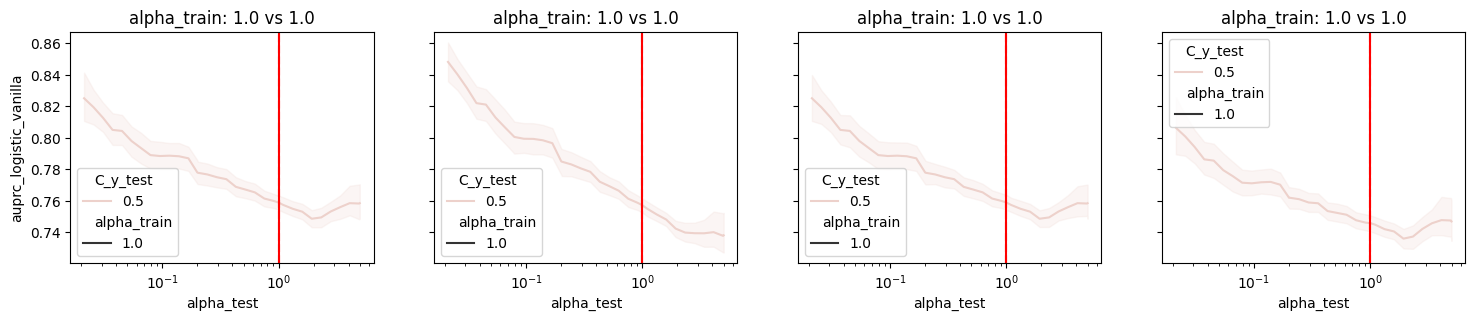

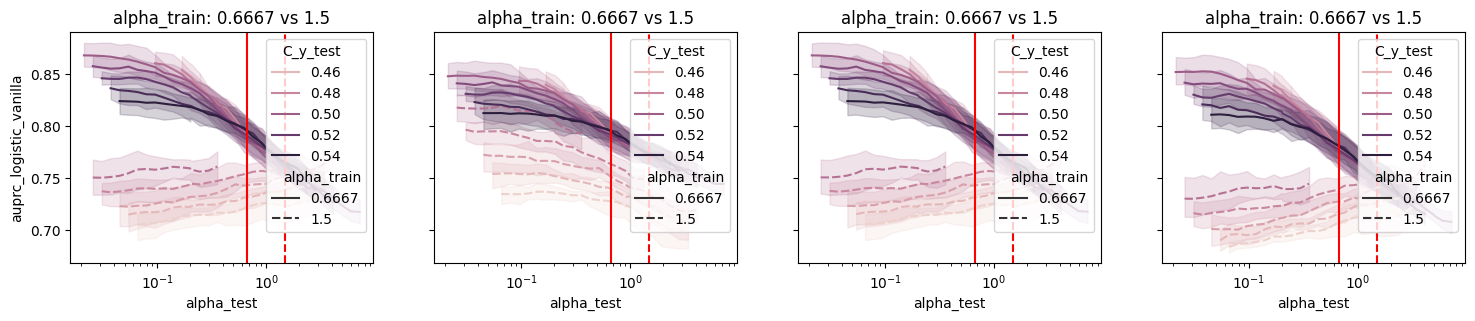

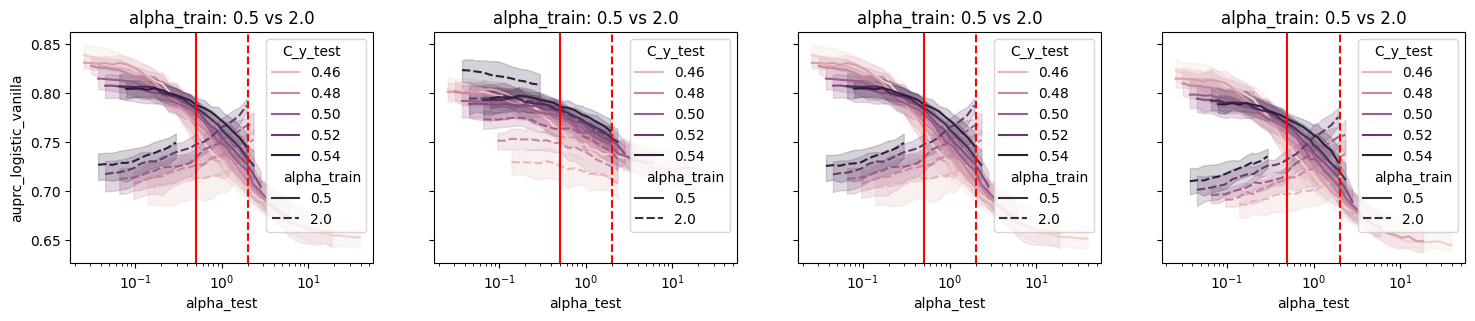

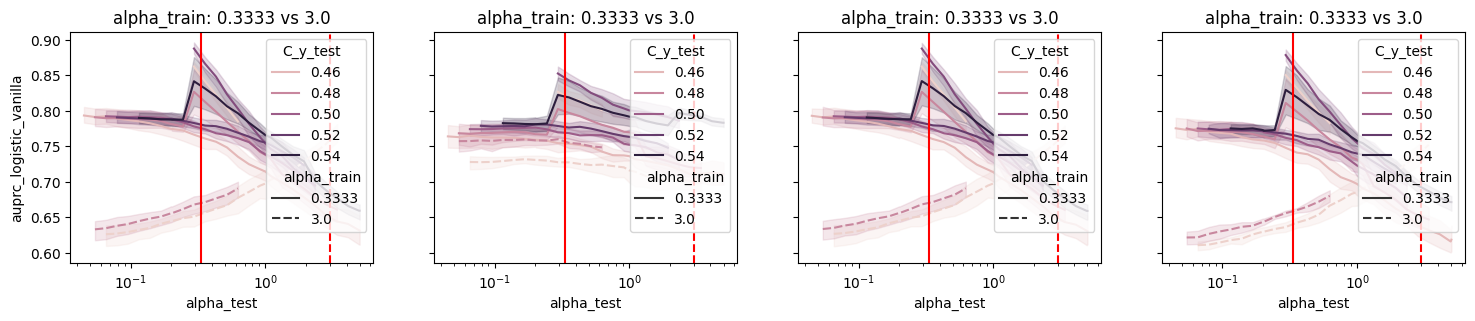

In [14]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(2)
# _df = _df[_df['C_y'].isin(list(np.arange(0.1,1,0.1)))]
# _df = _df[_df['C_y']==0.5]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,4, figsize=(18,3), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[1])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_naiveLossBalance', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[2])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[3])
        

        for i in range(4):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.8,1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [15]:
sum(df['C_y_test'] != df['C_y'])

0

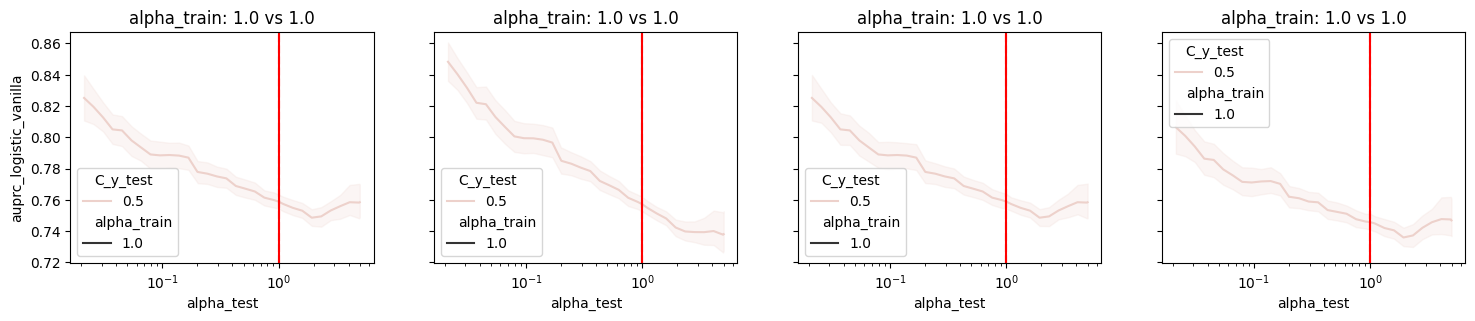

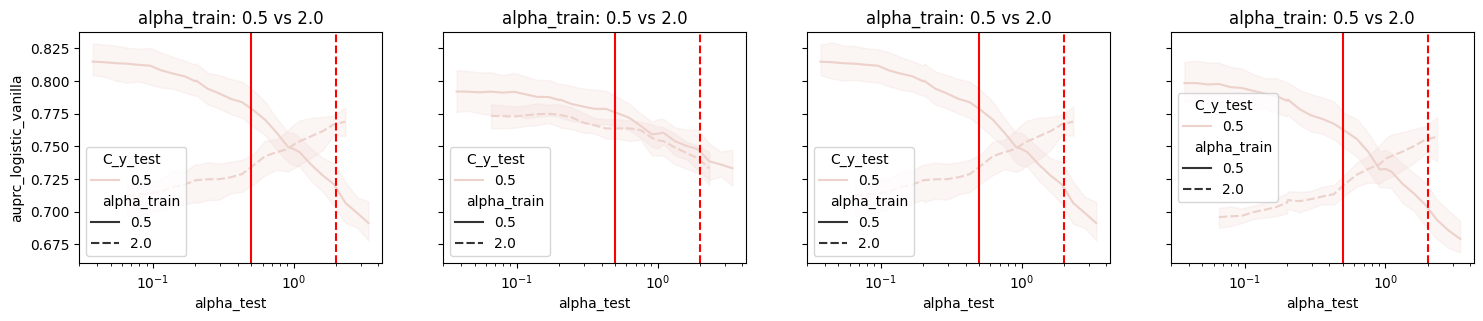

In [16]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(2)
# _df = _df[_df['C_y_test'].isin(list(np.arange(0.1,1,0.2).round(2)))]
_df = _df[np.isclose(_df['C_y_test'],0.5)]

# _df = _df[_df['C_y']==0.5]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,4, figsize=(18,3), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[1])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_naiveLossBalance', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[2])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[3])

        for i in range(4):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.8, 1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
_df.columns

In [ ]:
# from sklearn.preprocessing import minmax_scale

# colors_ = range(df_summary['cy'].nunique())
# discrete_colors = sample_colorscale('Bluered', minmax_scale(colors_))


In [ ]:
tmp = df.groupby('C_y_test', as_index=False).size()
tmp.sort_values("size", ascending=False)

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)



# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
#              hue='C_y',
#              ax=ax[0])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
#              hue='C_y',
#              ax=ax[1])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
#              hue='C_y',
#              ax=ax[2])

fig = px.scatter_3d(_df, x='alpha_train', y='alpha_test', z='auprc_logistic_vanilla',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

fig = px.scatter_3d(_df, x='C_y', y='C_y_test', z='auprc_logistic_vanilla',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

# fig = go.Figure(data=[go.Surface(z=_df['auprc_logistic_vanilla'], x=_df['C_y'], y=_df['C_y_test'])])
# fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])
# fig.update_layout(title='Wwwwt?', autosize=True,
#                   width=500, height=500,
#                   # margin=dict(l=65, r=50, b=65, t=90)
#                  )
fig.show()

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)



# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
#              hue='C_y',
#              ax=ax[0])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
#              hue='C_y',
#              ax=ax[1])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
#              hue='C_y',
#              ax=ax[2])

# fig = px.scatter_3d(_df, x='alpha_train', y='alpha_test', z='auprc_logistic_vanilla',
#               color='auprc_logistic_vanilla', 
#                     # size='petal_length', size_max=18,
#               # symbol='species', 
#                     opacity=0.7)

fig = px.scatter_3d(_df, x='C_y', y='C_y_test', z='auprc_logistic_IW',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

# fig = go.Figure(data=[go.Surface(z=_df['auprc_logistic_vanilla'], x=_df['C_y'], y=_df['C_y_test'])])
# fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])
# fig.update_layout(title='Wwwwt?', autosize=True,
#                   width=500, height=500,
#                   # margin=dict(l=65, r=50, b=65, t=90)
#                  )
fig.show()

In [ ]:

fig = px.scatter(df_summary, x="predMidpoint", y="coef", 
                 error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 error_y="coef_lowerdiff", error_y_minus="coef_upperdiff",
                 color="cy", facet_col="loraR", facet_row="model_size",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 color_continuous_scale=px.colors.sequential.Emrld,
                 # color_discrete_sequence=discrete_colors,
                 width=1400, height=1000,
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
              
              
fig.show()



In [ ]:
y_name = "auprc_weightsEdited"
x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.8,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]



n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate(["auprc_weightsEdited"]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
_df = df.copy()
_df['C_y1'] = np.floor(_df['C_y']*10)/10
_df['C_y'] = _df['C_y'].round(2)

In [ ]:
dfgrp = _df.groupby(['C_y1', 'C_y'], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False)
dfgrp = dfgrp.groupby("C_y1", as_index=False).head(1)

In [ ]:
dfgrp

In [ ]:
y_name = "auprc_weightsEdited"
x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.8,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate(["auprc_weightsEdited"]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

## One Plot For Lora Fine-tuning Set

In [8]:
fname

'../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5'

In [9]:
df.columns

Index(['auprc_weightsEdited', 'auprc_weightsEdited_df0',
       'auprc_weightsEdited_df1', 'precision_weightsEdited',
       'recall_weightsEdited', 'f1_weightsEdited',
       'precision_weightsEdited_df0', 'recall_weightsEdited_df0',
       'f1_weightsEdited_df0', 'precision_weightsEdited_df1',
       'recall_weightsEdited_df1', 'f1_weightsEdited_df1',
       'auroc_weightsEdited', 'auroc_weightsEdited_df0',
       'auroc_weightsEdited_df1', 'p_pos_train_z0', 'p_pos_train_z1',
       'p_pos_train', 'p_pos_test', 'p_mix_z0', 'p_mix_z1', 'alpha_train',
       'alpha_test', 'p_pos_test_z0', 'p_pos_test_z1', 'C_y', 'C_z',
       'C_y_test', 'n_train', 'n_test', 'n_z0_pos_train', 'n_z0_neg_train',
       'n_z0_pos_test', 'n_z0_neg_test', 'n_z1_pos_train', 'n_z1_neg_train',
       'n_z1_pos_test', 'n_z1_neg_test', 'run'],
      dtype='object')

In [10]:
# sum(df['C_y'] != df["C_y_test"])

In [11]:
_df = df.copy()
_df['C_y1'] = np.floor(_df['C_y']*10)/10
_df['C_y'] = _df['C_y'].round(2)

In [12]:
dfgrp = _df.groupby(['C_y1', 'C_y'], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False)
dfgrp = dfgrp.groupby("C_y1", as_index=False).head(1)

In [13]:
dfgrp

,C_y1,C_y,size
40,0.5,0.50,1815
30,0.4,0.40,1515
20,0.3,0.30,1075
50,0.6,0.60,1045
16,0.2,0.26,720
60,0.7,0.70,555
8,0.1,0.18,280
69,0.8,0.80,205
79,0.9,0.90,15


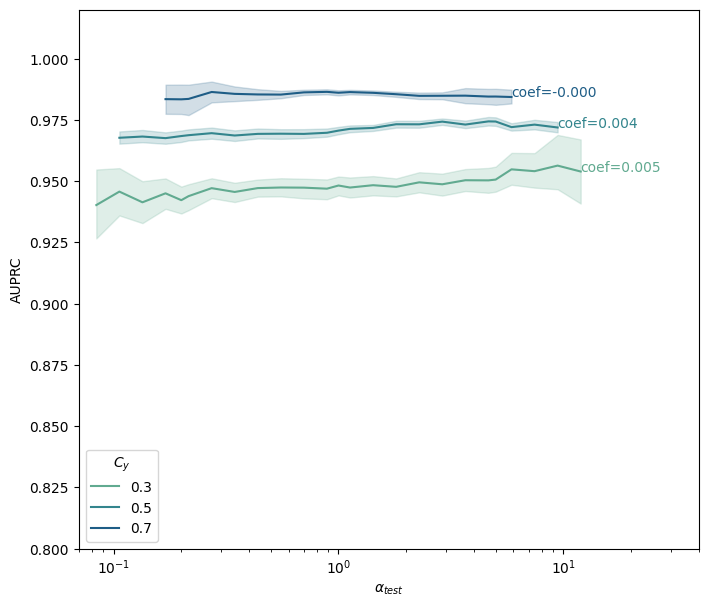

In [14]:
y_name = "auprc_weightsEdited"
# y_name = "auroc_weightsEdited"
# y_name = "f1_weightsEdited"

x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


# _df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()
_df_plt = _df[_df['C_y'].isin([0.3,0.5,0.7])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    ylim = 0.8,1.02
    # ylim = None
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
# ax.set_ylabel(y_name)
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate([y_name]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
# y_name = "auprc_weightsEdited"
y_name = "auroc_weightsEdited"
# y_name = "f1_weightsEdited"

x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.7,1.02
    # ylim=None
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
# ax.set_ylabel("AUPRC")
ax.set_ylabel(y_name)
# ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))


x=np.quantile(sorted(_df_plt[x_name]),1)

if dataset_name == "SHAC":
    y=np.quantile(sorted(_df_plt[y_name]),0.5)
    y=np.mean(sorted(_df_plt[y_name]))
elif dataset_name == 'HateSpeech':
    y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    reg = get_regression(x=_df_plt[x_name], y=_df_plt[y_name])
elif x_name in ["alpha_test"]:
    reg = get_coefLog10(x=_df_plt[x_name], y=_df_plt[y_name])



ax.text(x,y, f"coef={coef:.3f}", color=color)


plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
_df.columns

In [ ]:
y_name = "f1_weightsEdited"
x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.6,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel(f"{y_name}")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate(["auprc_weightsEdited"]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
# def conditionWass1d(distrListA, distrListB, conditionListZ):
#     ret = 0
#     for distrA, distrB, condZ in zip(distrListA, distrListB, conditionListZ):
        
#         ret_inner = scipy.stats.wasserstein_distance(np.arange(2), np.arange(2), distrA,distrB)
#         ret_condition = ret_inner * condZ
        
#         ret += ret_condition
        
#     return ret
    

# p_pos_train_z0 = 0.2
# p_pos_train_z1 = 0.2
# p_mix_z0 = 0.5
# p_mix_z1 = 1 - p_mix_z0


# distriListA = [[p_pos_train_z0, 1-p_pos_train_z0],[p_pos_train_z1, 1-p_pos_train_z1]]
# conditionListC = [p_mix_z0, p_mix_z1]


# df['distance_KL_Train_Test'] = df.apply(lambda x: conditionKL(
#     distriListA,
#     [[x['p_pos_test_z0'], 1-x['p_pos_test_z0']],[x['p_pos_test_z1'], 1-x['p_pos_test_z1']]],
#     conditionListC
#                                                    ),
#                                               axis=1
#                                              )


# df['distance_KL_Test_Train'] = df.apply(lambda x: conditionKL(
#     [[x['p_pos_test_z0'], 1-x['p_pos_test_z0']],[x['p_pos_test_z1'], 1-x['p_pos_test_z1']]],
#     distriListA,
#     [x['p_mix_z0'], x['p_mix_z1']]
#                                                    ),
#                                               axis=1
#                                              )




# # df['distance_EMD'] = df.apply(lambda x: conditionWass1d(
# #     distriListA,
# #     [[x['p_pos_test_z0'], 1-x['p_pos_test_z0']],[x['p_pos_test_z1'], 1-x['p_pos_test_z1']]],
# #     conditionListC
# #                                                    ),
# #                                               axis=1
# #                                              )



y_name = "auprc_weightsEdited"
# x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.8,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 3
fig, ax = plt.subplots(5,2, figsize=(18,20))
ax = ax.ravel()

for i,cy in enumerate(_df_plt['C_y'].unique()):
    _df_tmp = _df_plt[_df_plt['C_y'] == cy]
    sns.lineplot(data=_df_tmp, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax[i])

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
# x_name = "distance_KL_Train_Test"
# x_name = "distance_EMD"

sns.lineplot(data=df, x="alpha_test", y="distance_KL_Train_Test")

In [ ]:
# x_name = "distance_KL_Train_Test"
# x_name = "distance_EMD"

sns.lineplot(data=df, x="alpha_test", y="distance_KL_Test_Train")

In [ ]:
# x_name = "distance_KL_Train_Test"
# x_name = "distance_EMD"

sns.lineplot(data=df, x="alpha_test", y="distance_EMD")

In [ ]:
## Target for One setting -- For Bigger Ones!!!
## Plotting: save coef
## SAVE!!! plot

a_train = [3]

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query(f"alpha_train.isin({a_train})")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    # _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.4,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = (x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef:.3f}", color=color)
        
    

# plt.show()
outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
plt.savefig(outname, dpi=600)
plt.close()

## Only One Plot

In [ ]:
fname

In [ ]:
_df = df.copy()
_df['C_y1'] = np.floor(_df['C_y']*10)/10
_df['C_y'] = _df['C_y'].round(2)

dfgrp = _df.groupby(['C_y1', 'C_y'], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False)
dfgrp = dfgrp.groupby("C_y1", as_index=False).head(1)


y_name = "auprc_logistic_vanilla"
x_name = "alpha_test"

_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.7,1.02
    ylim = 0.4, 1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)


ax.set_xscale('log')
xlab = r"$\alpha_{test}$"
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate([y_name]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        
        reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
        pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()




In [ ]:
fname

In [ ]:
df.columns

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# y_name = 'auprc_lora'
y_name = "auprc_weightsEdited"
# _df = _df.query("C_y.isin([0.16, 0.3, 0.5, 0.75, 0.8])")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,n_cols, figsize=(8,7))
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y=y_name, style='alpha_train', hue='C_y', ax=ax)

        for i in range(n_cols):
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.axvline(reciprocal, color="red", linestyle='solid')
            ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
reg[1].summary()

In [ ]:
reg[1].get_prediction([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))]).summary_frame(alpha = 0.05)

In [ ]:
## Target for one setting...
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([3, 0.3333])")

# _df = _df.query("C_y.isin([0.17, 0.46,  0.75])")
# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    
    if alpha_train >= 1 :
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],
                     x='alpha_test',
                     y='auprc_logistic_vanilla', 
                     style='alpha_train', 
                     hue='C_y',
                     # hue="C_y_cut",
                     ax=ax,
                    )

        for i in range(n_cols):
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.axvline(reciprocal, color="red", linestyle='solid')
            ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))

            ax.set_ylim(0.7,1)
        plt.show()
plt.close()

In [ ]:
_df['C_y'].unique()

In [ ]:
## Target for one setting...
## remove reciprocal

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

# _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")

# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    

    
    fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

    sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) ],
                 x='alpha_test',
                 y='auprc_logistic_vanilla', 
                 style='alpha_train', 
                 hue='C_y',
                 # hue="C_y_cut",
                 ax=ax,
                )

    for i in range(n_cols):
        ax.set_xscale('log')
        ax.axvline(alpha_train, color="red", linestyle='dashed')
        ax.title.set_text("alpha_train: " + str(alpha_train))

        ax.set_ylim(0.7,1)
    plt.show()
plt.close()

In [ ]:
## Target for one setting...
## remove reciprocal
## SAVE!!! plot

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'HateSpeech':
    _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    ylim=0.5,1
    
    
    loc_legend = "best"
    loc_coef_x = -40
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.1, 0.5, 1,]
    
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim=0.6,1
    loc_legend = "best"
    loc_coef_x = -30
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.2, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    

    
    fig, ax = plt.subplots(1,n_cols, figsize=(5,4))

    sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) ],
                 x='alpha_test',
                 y='auprc_logistic_vanilla', 
                 hue='C_y',
                 palette=palette,
                 
                 style='C_y',
                 ax=ax,
                )
    
    
    for item, color in zip(_df.groupby('C_y'), palette):        
        for ylabel in ['auprc_logistic_vanilla']:
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            coef = get_coefLog10(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))[0]

            ax.text(x, y, f"coef={coef:.3f}", color=color)
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.set_ylim(ylim)
            
            ax.legend(loc=loc_legend, title=r'$C_y$')
            ax.xaxis.set_major_formatter(ScalarFormatter())
            ax.set_xticks(xticks)

            ax.title.set_text(r"$\alpha_{train}$ = " + str(alpha_train))
            ax.set_xlabel(r"$\alpha_{test}$")
            ax.set_ylabel("AUPRC")
        

        
plt.show()    
# plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

In [ ]:
list(sorted(_df.C_y.unique()))

In [ ]:
fname

In [ ]:
list(df.query("(alpha_train==1)")['C_y'].unique())

In [ ]:
# better version for save
xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel).copy().reset_index(drop=True)

_df['C_y'] = _df['C_y'].round(4)
_df = _df.query("C_y.isin([0.2,0.4,0.5,0.6,0.8,0.9])")

# names_auprc = ['auprc_logistic_vanilla', 'auprc_logistic_confounder']
names_auprc = ['auprc_logistic_vanilla']

_df = _df.melt(id_vars = [xlabel, "C_y"], value_vars=names_auprc, var_name="auprcName", value_name="auprc")


g_results=sns.lineplot(data=_df, x=xlabel, y='auprc', ax=ax, hue="auprcName", style="C_y")

# g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA", style="C_y")
# g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", style="C_y")
# g_results.set(xscale="log")

# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
# ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
# sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
# g_results.set(xticks=sample_count)
# g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
_df = df.copy()
_df = _df.query("alpha_train.isin([1,4, 0.25])").reset_index(drop=True)


fig, ax = plt.subplots(1,1, figsize=(8,8))

# sns.lineplot(data = _df, x='alpha_test', y='distance_KL_Train_Test', ax=ax, hue="alpha_train")
sns.lineplot(data = _df, y='alpha_test', x='distance_KL_Train_Test', ax=ax, hue="alpha_train")

ax.set_xscale("log")

In [ ]:
_df = df.copy()
_df = _df.query("alpha_train.isin([1,4, 0.25])").reset_index(drop=True)


fig, ax = plt.subplots(1,1, figsize=(8,8))

sns.lineplot(data = _df, x='alpha_test', y='distance_KL_Train_Test', ax=ax, hue="alpha_train")

ax.set_xscale("log")

In [ ]:
fname

In [ ]:
######  Saving
# better version for save
# regular x scale

xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()[1:-1]
# p_mix_z1 = df['p_mix_z1'].unique()[1:4]
p_mix_z1 = [0.3,0.5,0.6]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(15,4))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'].round(2) == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    # g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")


plt.tight_layout()

plt.savefig(f"{fname}.png", dpi=400)
plt.close()

In [ ]:
######  Saving
# better version for save
# log scale of x


xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()[1:-1]
# p_mix_z1 = df['p_mix_z1'].unique()[1:4]
p_mix_z1 = [0.3,0.5,0.6]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(15,4), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'].round(2) == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}", fontsize=16)
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    ax[idx].set_xlabel(r"$\alpha_{test}$", fontsize=16)
    ax[idx].set_ylabel("AUPRC", fontsize=16)
    
    sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    g_results.set(xticks=sample_count)
    g_results.set(xticklabels=sample_count)
    
    # ylabels = ['{:,.2f}'.format(x) for x in ax[idx].get_yticks()]
    # ax[idx].set_yticklabels(ylabels)
    
    # for SentenceBERT
    # ax[idx].set_ylim(0.81,0.95)
    
    ax[idx].xaxis.set_tick_params(labelsize=14)
    ax[idx].yaxis.set_tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(f"{fname}_logScale.png", dpi=400)
plt.close()

In [ ]:
# better version for save
# xlabel = "alpha_test"
xlabel = "distance_EMD"
# xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    # g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=f"{xlabel}", ylabel="AUPRC")
    # sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    # g_results.set(xticks=sample_count)
    # g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values("alpha_test")
    
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df0', ax=ax[idx], label="confounder-df0", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df1', ax=ax[idx], label="confounder-df1", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df0', ax=ax[idx], label="vanilla-df0", alpha=0.6,linestyle='dashed')
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df1', ax=ax[idx], label="vanilla-df1", alpha=0.6,linestyle='dashed')
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_confounder'], label="confounder")
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_vanilla'], label="vanilla")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()
plt.tight_layout()

In [ ]:
xlabel = "distance_EMD"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df0', ax=ax[idx], label="confounder-df0", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df1', ax=ax[idx], label="confounder-df1", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df0', ax=ax[idx], label="vanilla-df0", alpha=0.6,linestyle='dashed')
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df1', ax=ax[idx], label="vanilla-df1", alpha=0.6,linestyle='dashed')
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_confounder'], label="confounder")
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_vanilla'], label="vanilla")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()
plt.tight_layout()

In [ ]:
xlabel = "distance_EMD"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,10), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="confounder")
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla")
    
    ax[idx].set_xlabel(xlabel)
    ax[idx].set_ylabel("AUPRC")
    # ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()

plt.tight_layout()

In [ ]:
xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,10))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="confounder")
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla")
    
    ax[idx].set_xlabel(xlabel)
    ax[idx].set_ylabel("AUPRC")
    # ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()

plt.tight_layout()

In [ ]:
# xlabel = "distance_KL_Train_Test"
xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


In [ ]:
xlabel = "distance_KL_Train_Test"
# xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


In [ ]:
xlabel = "distance_KL_Train_Test"
# xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


## Summary Plot

### Task Vector Results

In [146]:
## Two lambdas
dataset_name = "SHAC"
# dataset_name = "HateSpeech"

# subdir = "original"
# subdir = "threeLambdas"
subdir = "ReverseSource"

if dataset_name == "SHAC":
    outdir =f"../output/tmpData/SHAC/summary/{subdir}"
    set_levels = [11063,6114,1152]
    
    if subdir == 'original':
        lambda_levels = ["1.0-0.0", "1.05-0.05", "1.1-0.1", "1.3-0.3", "1.5-0.5", "1.7-0.7", "2.0-1.0", "3.0-2.0", "4.0-3.0"]  # discard 1.0-1.0
        # lambda_levels = ["1.0-0.0", "1.5-0.5"]
        lambdaVar = "lambda1_lambda2"
        hue_kws={}
    elif subdir == 'ReverseSource':
        lambda_levels = ["1.0-0.0", "1.05-0.05", "1.1-0.1", "1.3-0.3", "1.5-0.5", "1.7-0.7", "2.0-1.0", "1.0-1.0"]
        # lambda_levels = ["1.0-0.0", "1.5-0.5"]
        lambdaVar = "lambda1_lambda2"
        hue_kws={}
    elif subdir == 'threeLambdas':
        lambda_levels = ["1.0-0.0-0.0","2.0-1.0-0.0","2.0-0.0-1.0", "1.6-0.3-0.3", "2.0-0.5-0.5", "2.6-0.8-0.8", "3.0-1.0-1.0"]
        # lambda_levels = ["1.6-0.3-0.3"]
        lambdaVar = "lambda1_lambda2_lambda3"
        hue_kws={"marker" : ["o","D","X","o","o","o","o"]}
        
    
elif dataset_name == "HateSpeech":
    outdir = "../output/tmpData/HateSpeech/summary/"
    set_levels = [9870, 6126, 1874]
    lambda_levels = ["1.0-0.0", "1.0-0.5", "2.0-1.0", "3.0-1.0"]
    
df_list = []
for file_i in Path(outdir).glob("Eval-*"):
    tmpdf = pd.read_csv(file_i)
    df_list.append(tmpdf)
        

        
df_summary = pd.concat(df_list).reset_index(drop=True)

if subdir == "threeLambdas":
    df_summary["lambda1_lambda2_lambda3"] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}-{x['lambda3']}", axis=1)
else:
    df_summary[lambdaVar] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

df_summary[lambdaVar] = pd.Categorical(df_summary[lambdaVar], categories=lambda_levels)

In [147]:
df_summary

,Unnamed: 0,cy,coef,predMidpoint,pred_lower,pred_upper,pred_se,coef_lower,coef_upper,y_min,...,y_alpha_train_recip,name,set,lambda1,lambda2,pred_lowerdiff,pred_upperdiff,coef_lowerdiff,coef_upperdiff,lambda1_lambda2
0,0,0.18,-0.020360,0.944448,0.941334,0.947562,0.001582,-0.025926,-0.014794,0.859440,...,0.936670,Eval-set-11063-quantization-epoch3-llama-2-7B-...,11063,1.1,0.1,0.003114,0.003114,0.005566,0.005566,1.1-0.1
1,1,0.26,-0.016866,0.951496,0.949973,0.953020,0.000776,-0.020254,-0.013477,0.888156,...,0.938911,Eval-set-11063-quantization-epoch3-llama-2-7B-...,11063,1.1,0.1,0.001524,0.001524,0.003389,0.003389,1.1-0.1
2,2,0.30,-0.017073,0.954791,0.953727,0.955855,0.000542,-0.019415,-0.014731,0.899281,...,0.941368,Eval-set-11063-quantization-epoch3-llama-2-7B-...,11063,1.1,0.1,0.001064,0.001064,0.002342,0.002342,1.1-0.1
3,3,0.40,-0.014335,0.965588,0.965064,0.966112,0.000267,-0.015452,-0.013218,0.928507,...,0.956085,Eval-set-11063-quantization-epoch3-llama-2-7B-...,11063,1.1,0.1,0.000524,0.000524,0.001117,0.001117,1.1-0.1
4,4,0.50,-0.011231,0.974030,0.973706,0.974355,0.000165,-0.011877,-0.010585,0.950131,...,0.966488,Eval-set-11063-quantization-epoch3-llama-2-7B-...,11063,1.1,0.1,0.000324,0.000324,0.000646,0.000646,1.1-0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,4,0.50,0.020905,0.964431,0.964043,0.964820,0.000198,0.020132,0.021679,0.939036,...,0.949177,Eval-set-1152-quantization-epoch3-llama-2-7B-l...,1152,1.5,0.5,0.000388,0.000388,0.000773,0.000773,1.5-0.5
212,5,0.60,0.018333,0.974294,0.973874,0.974714,0.000214,0.017206,0.019460,0.948631,...,0.959829,Eval-set-1152-quantization-epoch3-llama-2-7B-l...,1152,1.5,0.5,0.000420,0.000420,0.001127,0.001127,1.5-0.5
213,6,0.70,0.012963,0.982612,0.982182,0.983042,0.000219,0.011386,0.014541,0.963199,...,0.971498,Eval-set-1152-quantization-epoch3-llama-2-7B-l...,1152,1.5,0.5,0.000430,0.000430,0.001577,0.001577,1.5-0.5
214,7,0.80,0.008275,0.989012,0.988461,0.989563,0.000279,0.005473,0.011076,0.979905,...,NaN,Eval-set-1152-quantization-epoch3-llama-2-7B-l...,1152,1.5,0.5,0.000551,0.000551,0.002801,0.002801,1.5-0.5


In [148]:
df_summary['set'] = pd.Categorical(df_summary['set'], categories=set_levels)

In [149]:
df_summary['cy'].unique()

array([0.18, 0.26, 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 ])

In [150]:
sns.set_theme()
sns.set_context("paper")

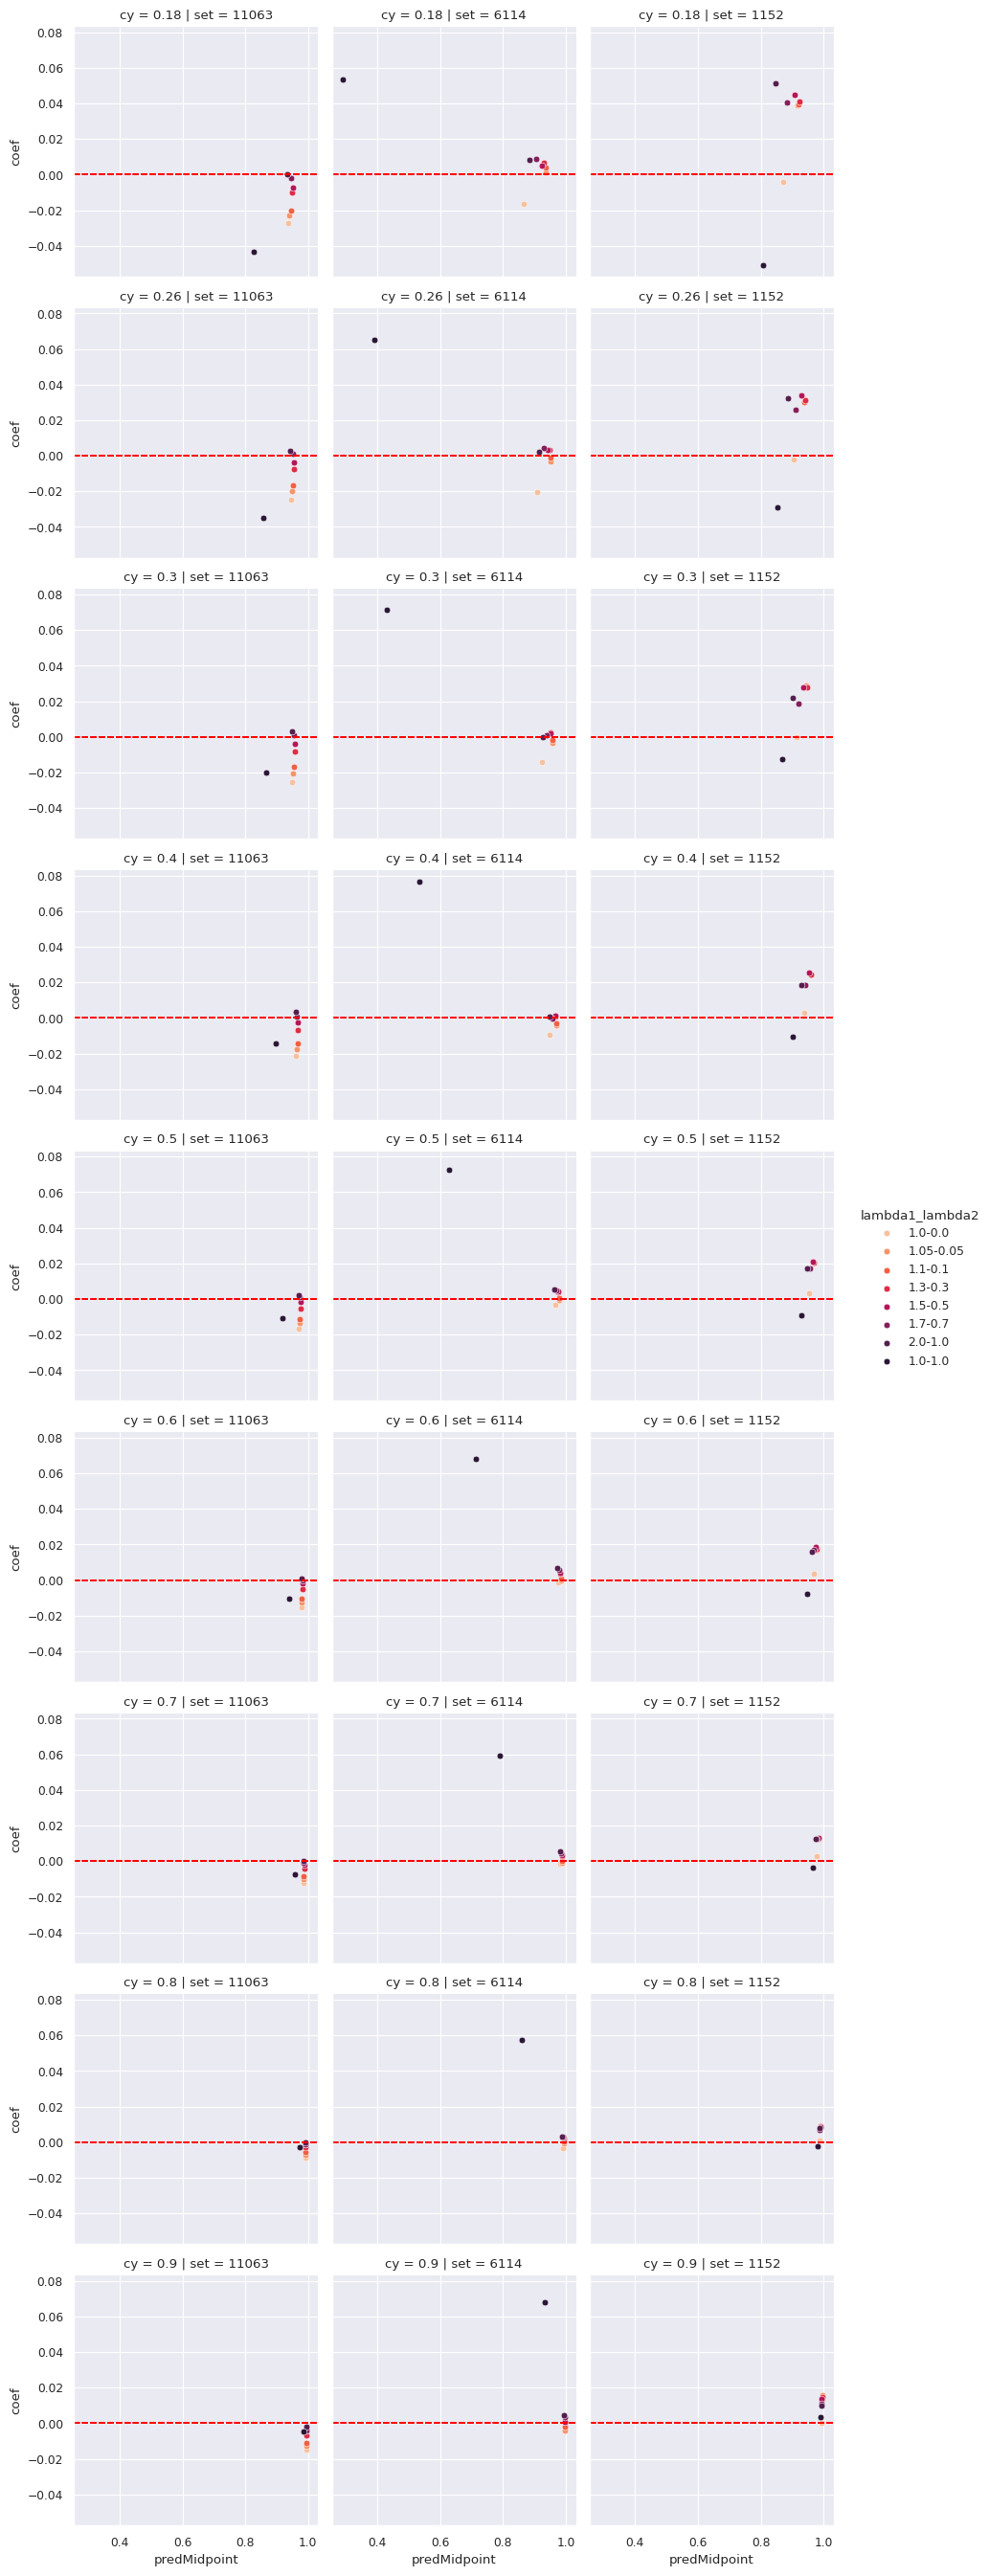

In [151]:
my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

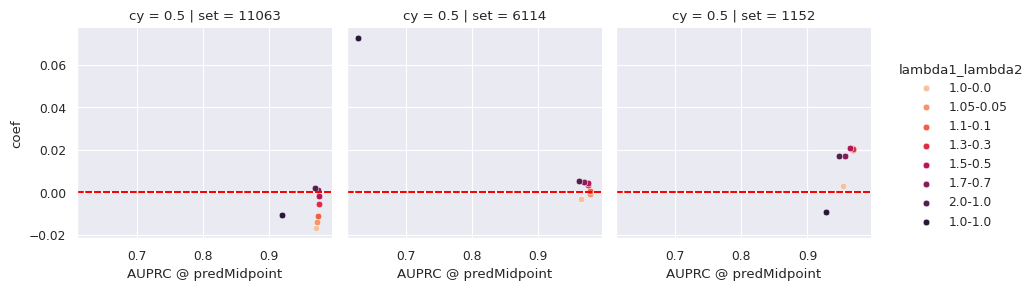

In [152]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.set(xlabel="AUPRC @ predMidpoint")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

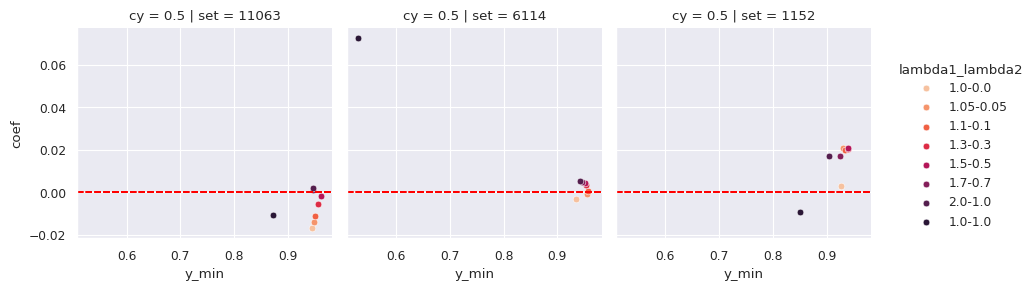

In [153]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_min", "coef")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

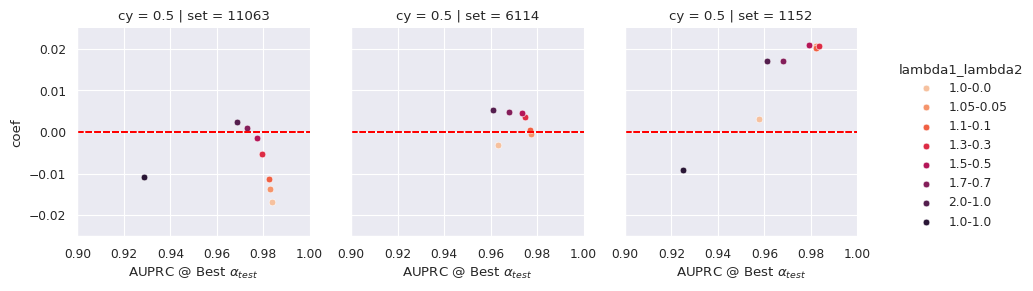

In [154]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train", "coef")
g.set(xlabel=r"AUPRC @ Best $\alpha_{test}$")

g.add_legend()
g.set(ylim=(-0.025,0.025))
g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

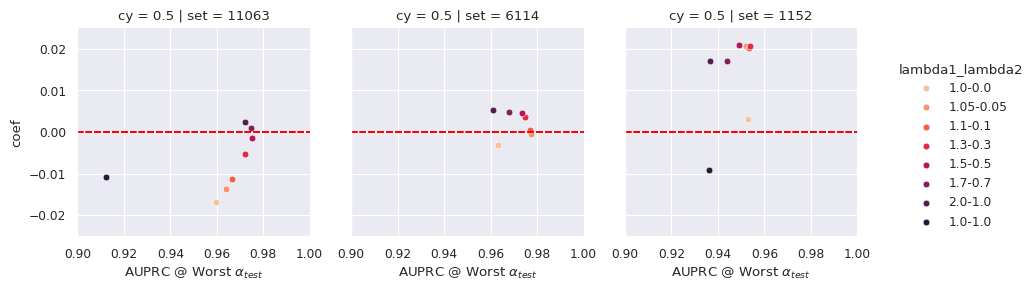

In [155]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
g.set(ylim=(-0.025,0.025))
# g.set(ylim=(-0.04,0.04))

g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

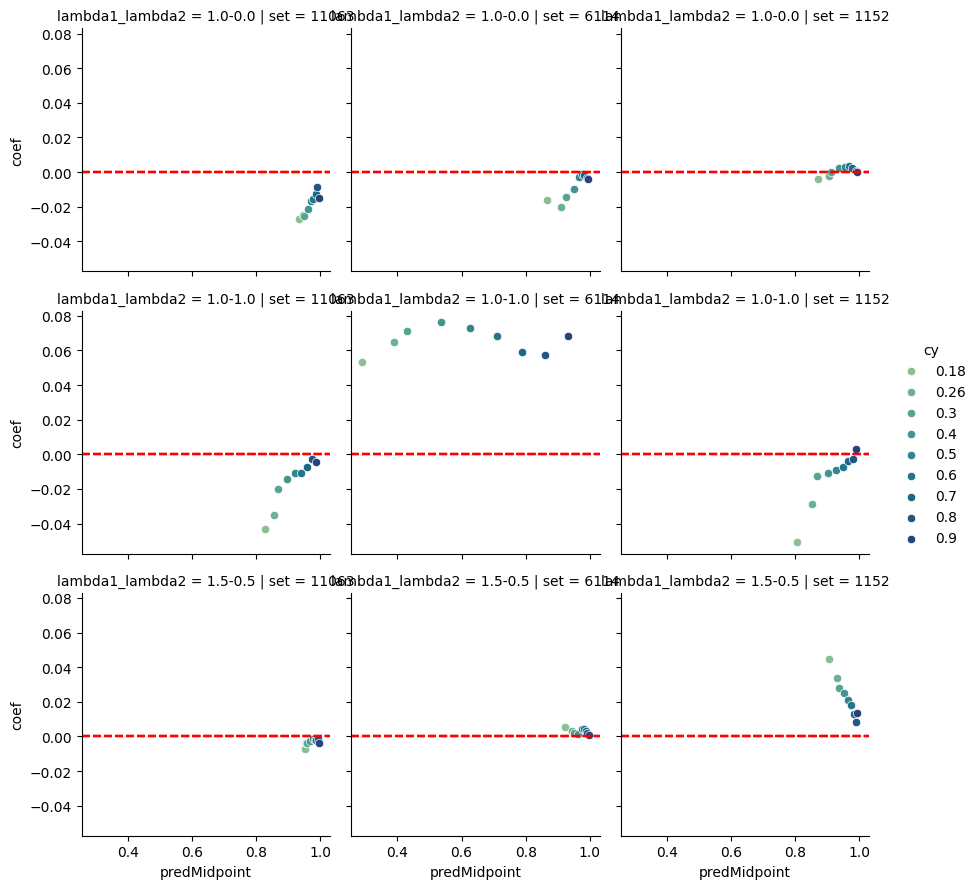

In [39]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')



my_palette = sns.color_palette("crest", df_summary['cy'].nunique())

g = sns.FacetGrid(data=df_summary, row=lambdaVar, col='set', hue='cy', height=3, palette=my_palette)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
_df.columns

In [ ]:
_df = deepcopy(df_summary)
# _df['alpha_train'] = _df['alpha_train'].round(4)



# # sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
# #              hue='C_y',
# #              ax=ax[0])
# # sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
# #              hue='C_y',
# #              ax=ax[1])
# # sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
# #              hue='C_y',
# #              ax=ax[2])



fig = px.scatter_3d(_df, x='C_y', y='C_y_test', z='auprc_logistic_vanilla',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

In [ ]:
_df.cy.unique()

### LoRA Fine Tune - Many R and Model Size Results

In [ ]:
outdir = "../output/tmpData/SHAC/summary/"
for file_i in Path(outdir).glob("LoRA_*"):
    print(file_i)

In [ ]:
dataset_name = "SHAC"
# dataset_name = "HateSpeech"

if dataset_name == "SHAC":
    outdir = "../output/tmpData/SHAC/summary/"
    modelsize_levels = ["7B", "13B", "70B"]
    loraR_levels = [2,8,32,64]

df_list = []
for file_i in Path(outdir).glob("LoRA_*"):
    tmpdf = pd.read_csv(file_i)
    df_list.append(tmpdf)

In [ ]:
df_summary = pd.concat(df_list)

In [ ]:
df_summary

In [ ]:
df_summary['model_size'] = pd.Categorical(df_summary['model_size'], categories=modelsize_levels)

df_summary['loraR'] = pd.Categorical(df_summary['loraR'], categories=loraR_levels)

In [ ]:
df_summary['cy'].unique()

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary['loraR'].nunique())

g = sns.FacetGrid(data=df_summary, row='cy', col='model_size', hue='loraR', palette=my_palette)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary['model_size'].nunique())

g = sns.FacetGrid(data=df_summary, row='cy', col='loraR', hue='model_size', palette=my_palette, )
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')



my_palette = sns.color_palette("crest", df_summary['cy'].nunique())

g = sns.FacetGrid(data=df_summary, row='model_size', col='loraR', hue='cy', height=3, palette=my_palette)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
from sklearn.preprocessing import minmax_scale

colors_ = range(df_summary['cy'].nunique())
discrete_colors = sample_colorscale('Bluered', minmax_scale(colors_))


In [ ]:

fig = px.scatter(df_summary, x="predMidpoint", y="coef", 
                 error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 error_y="coef_lowerdiff", error_y_minus="coef_upperdiff",
                 color="cy", facet_col="loraR", facet_row="model_size",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 color_continuous_scale=px.colors.sequential.Emrld,
                 # color_discrete_sequence=discrete_colors,
                 width=1400, height=1000,
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
              
              
fig.show()



In [ ]:

n_colors=len(loraR_levels) + 1  # discard 1st color, since it's too faint
my_palette = px.colors.sample_colorscale("deep", [n/(n_colors -1) for n in range(n_colors)])[1:]

fig = px.scatter(df_summary.query("cy==0.5"), 
                 x="predMidpoint", y="coef", 
                 error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 error_y="coef_lowerdiff", error_y_minus="coef_upperdiff",
                 color="loraR", facet_col="model_size", facet_row="cy",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 # color_continuous_scale=px.colors.sequential.Emrld,
                 color_discrete_sequence=my_palette,
                 width=1000, height=400,
                 
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
              
              
fig.show()



In [ ]:

n_colors=len(loraR_levels) + 1  # discard 1st color, since it's too faint
my_palette = px.colors.sample_colorscale("deep", [n/(n_colors -1) for n in range(n_colors)])[1:]

fig = px.scatter(df_summary.query("cy.isin( [0.3,0.5,0.7] )"), 
                 x="y_min", y="coef", 
                 # error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 
                 color="loraR", facet_col="model_size", facet_row="cy",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 # color_continuous_scale=px.colors.sequential.Emrld,
                 color_discrete_sequence=my_palette,
                 width=1000, height=800,
                 
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
fig.update_traces(marker={'size': 12, 'opacity':0.8})      
              
fig.show()



In [ ]:
pd.factorize(df_summary['cy'])

In [ ]:
# # sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')
# import matplotlib as mpl

# # cmap=mpl.colormaps["Purples"]
# cmap = plt.cm.get_cmap('Purples', 10)
# grp = df_summary.groupby(['model_size', 'loraR'])

# my_palette = sns.color_palette("crest", df_summary['cy'].nunique(), as_cmap=True)


# fig, ax = plt.subplots(df_summary['model_size'].nunique(), df_summary['loraR'].nunique(), figsize=(20,16), sharey=True)

# ax = ax.ravel()
# for idx, item in enumerate(grp):
    
    
#     ax[idx].errorbar(item[1]['predMidpoint'], item[1]['coef'],
#                      xerr=[item[1]['pred_lowerdiff'], item[1]['pred_upperdiff']],
#                      yerr=[item[1]['coef_lowerdiff'], item[1]['coef_upperdiff']],
#                      # lolims=item[1]['pred_lower'], uplims=item[1]['pred_upper'], 
#                      fmt='o',
#                      # marker='o', linestyle="none",
#                      color='red',
#                     )
    
    
    
    
# ax.errorbar(x, y + 1.5, xerr=xerr, yerr=yerr,
#             lolims=lolims, uplims=uplims,
#             marker='o', markersize=8,
#             linestyle=ls)    
# for item, color in zip(1, palette):
#     print(item)
#     _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
#     g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
#     g_results.set(xscale="log")
    
#     ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
#     ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
#     ax[idx].legend()
#     ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
#     sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
#     g_results.set(xticks=sample_count)
#     g_results.set(xticklabels=sample_count)

# plt.tight_layout()


# g = sns.FacetGrid(data=df_summary, row='model_size', col='loraR', hue='cy', height=3, palette=my_palette)
# g.map(sns.scatterplot, "predMidpoint", "coef")
# g.add_legend()

# g.map(plt.axhline, y=0, ls='--', c='red')

## Scatter Plot

In [ ]:

fig, ax = plt.subplots(1,2, figsize=(28,10))
xlabel = "distance_KL_Test_Train"
_df = df.sort_values(xlabel)

for idx, k in enumerate(["auprc_logistic_vanilla", "auprc_logistic_confounder"]):
    
    im = ax[idx].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], c=_df[k], cmap='Blues')
    im.set_clim(0.8,1)
    ax[idx].set_xlabel("p_pos_test_z0")
    ax[idx].set_ylabel("p_pos_test_z1")
    ax[idx].set_title(k)

    fig.colorbar(im, ax=ax[idx])

In [ ]:
pd.options.display.max_columns = None

In [ ]:

df[(df['p_pos_test_z0'].round(3)==0.3)
    & (df['p_pos_test_z1'].round(2)==0.3) 
    & (df['run']==0) 
    # & (df['p_mix_z1'].round(3)==0.4)
   ]


In [ ]:
sns.scatterplot(x="p_pos_test_z0", y="p_pos_test_z1", data=df.query("(run==0)"))

In [ ]:

auprc_vanilla_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==0.4)
                           & (_df['run']==0)]['auprc_logistic_vanilla'].values[0]


In [ ]:
auprc_vanilla_target

In [ ]:
df[
    (df['run']==0) 
    # & (df['p_mix_z1'].round(3)==0.4)
    & (df['p_pos_test_z0'].round(3) == 0.5)
    & (df['p_pos_test_z1'].round(3) == 0.2)
   ]

In [ ]:
min(auprc_ba_target - _df["auprc_logistic_confounder"])

In [ ]:
max(auprc_vanilla_target - _df["auprc_logistic_vanilla"])

In [ ]:
from matplotlib import cm

fig, ax = plt.subplots(1,2, figsize=(7,3),dpi=400)
# xlabel = "distance_KL_Test_Train"



p_mix_z1 = 0.4
_df = df[
    (df['run']==0) 
    & (df['p_mix_z1'].round(3)==p_mix_z1)
   ].copy()






auprc_vanilla_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==p_mix_z1)
                           & (_df['run']==0)]['auprc_logistic_vanilla'].values[0]


auprc_ba_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==p_mix_z1)
                           & (_df['run']==0)]['auprc_logistic_confounder'].values[0]


im = ax[0].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], 
                   c=abs(auprc_vanilla_target - _df["auprc_logistic_vanilla"]), cmap='Blues',
                   s=2
                  )
im.set_clim(0,0.2)
ax[0].set(xlabel="p_pos_test_z0", ylabel="p_pos_test_z1", title="AUPRC Difference of vanilla")

fig.colorbar(im, ax=ax[0])



im = ax[1].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], 
                   c=abs(auprc_ba_target - _df["auprc_logistic_confounder"]), cmap='Blues',
                   s=2
                  )
im.set_clim(0,0.2)
ax[1].set(xlabel="p_pos_test_z0", ylabel="p_pos_test_z1", title="AUPRC Difference of BA")
# plt.ylabel("p_pos_test_z1")
# plt.title("AUPRC of BA")

fig.colorbar(im, ax=ax[1])



plt.tight_layout()

In [ ]:
df.query("0.67 < distance_KL_Test_Train < 0.75").sort_values("distance_KL_Test_Train")

## Check some diagnosis

### Corr Plot

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(pd.DataFrame(x_transform_test).iloc[:, :].corr(), vmin=-1, vmax=1)

### R2

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2_score(y_true=y_test, y_pred=y_probs_vanilla[:, 1])

In [ ]:
r2_score(y_true=y_test, y_pred=y_probs_confound[:, 1])

In [ ]:
def r2AndAdjusted(y_true, y_pred, np):
    n = len(y_true)
    
    r2 = r2_score(y_true=y_true, y_pred=y_pred)
    r2_adjusted = 1-(1-r2)*(n-1)/(n-np-1)
    
    return r2, r2_adjusted
    

In [ ]:
r2AndAdjusted(y_true=y_test, y_pred=y_probs_vanilla[:, 1], np=384)

In [ ]:
# auprc_logistic_confounder

# auprc_logistic_vanilla

In [ ]:
x_transform_train.shape

### Deviance Residuals

In [ ]:
def deviance(X, y, model):
    return 2*metrics.log_loss(y, model.predict_proba(X), normalize=False)

In [ ]:
deviance(X=x_transform_test, y=y_test, model=clf_vanilla)

### Calibration

In [ ]:
from sklearn.calibration import calibration_curve
prob_true_vanilla, prob_pred_vanilla = calibration_curve(y_true=y_test, y_prob=y_probs_vanilla[:,1], n_bins=10)
prob_true_confound, prob_pred_confound = calibration_curve(y_true=y_test, y_prob=y_probs_confound[:,1], n_bins=10)


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(prob_pred_vanilla, prob_true_vanilla, label='vanilla')
ax.plot(prob_pred_confound, prob_true_confound, label='confound')

ax.plot([0,1],[0,1], "--", color='gray')
ax.legend()
